# Imports

In [17]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pykitti
from pathlib import Path

# Load KITTI
base = Path.home() / 'SensorTrust' / 'datasets' / 'kitti'
data = pykitti.raw(base_path=str(base), date='2011_09_26', drive='0009')

from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies
from src.features.normalization import MotionNormalizer
from src.features.f1_kinematic import extract_all_f1_features
from src.features.f2_scene import compute_f2
from src.features.gmis import compute_gmis
from src.attacks.gps_attack import gps_speed_ramp, gps_step_offset
from src.attacks.imu_attack import attack_imu_proxies
from src.attacks.lidar_attack import inject_phantom_sequence
from src.attacks.camera_attack import gaussian_noise as cam_gaussian_noise

print("✅ All imports successful")
print(f"Frames: {len(data.oxts)}")

✅ All imports successful
Frames: 447


# Extract clean proxies

In [10]:
dt = 0.1035

gps_clean = extract_all_gps_proxies(data.oxts, dt=dt)
imu_clean = extract_all_imu_proxies(data.oxts, dt=dt)

camera_frames = [np.array(f) for f in list(data.cam2)]
cam_clean = extract_all_camera_proxies(camera_frames)

velo_scans = list(data.velo)
lidar_clean = extract_all_lidar_proxies(velo_scans, data.oxts[:len(velo_scans)])

print("✅ Clean proxies extracted")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
✅ Clean proxies extracted


# Fit normalizer:

In [11]:
normalizer = MotionNormalizer()
normalizer.fit(gps_clean, imu_clean, cam_clean, lidar_clean)

z_clean = normalizer.transform(gps_clean, imu_clean, cam_clean, lidar_clean)

print("✅ Normalizer fitted")

Normalization parameters fitted:
  gps_delta_v         : μ= -0.1212, σ=  0.4548
  gps_heading_rate    : μ=  0.0423, σ=  1.7530
  imu_delta_v         : μ= -0.1656, σ=  0.4658
  imu_yaw_rate        : μ=  0.0279, σ=  0.1016
  camera_flow         : μ= 11.7695, σ=  5.5256
  lidar_icp           : μ=  0.1131, σ=  0.0318
✅ Normalizer fitted


# Compute Clean features

In [12]:
f1_clean = extract_all_f1_features(z=z_clean, gps_speed=gps_clean['speed'])['f1']

min_len_f2 = min(len(z_clean['gps_delta_v']), len(z_clean['lidar_icp']))
f2_clean = compute_f2(z_clean['gps_delta_v'][:min_len_f2], z_clean['lidar_icp'][:min_len_f2])

min_len_gmis = min(len(z_clean['gps_delta_v']), len(z_clean['imu_delta_v']), 
                   len(z_clean['lidar_icp']), len(z_clean['camera_flow']))
gmis_clean = compute_gmis(z_clean['gps_delta_v'][:min_len_gmis],
                          z_clean['imu_delta_v'][:min_len_gmis],
                          z_clean['lidar_icp'][:min_len_gmis],
                          z_clean['camera_flow'][:min_len_gmis])

CLEAN_F1 = np.nanmean(f1_clean)
CLEAN_F2 = np.nanmean(f2_clean)
CLEAN_GMIS = np.nanmean(gmis_clean)

print("✅ Clean features computed")
print(f"F1:   mean={CLEAN_F1:.4f}")
print(f"F2:   mean={CLEAN_F2:.4f}")
print(f"GMIS: mean={CLEAN_GMIS:.4f}")

✅ Clean features computed
F1:   mean=0.5598
F2:   mean=0.9053
GMIS: mean=0.8221


# Helper function:

In [19]:
def run_attack(name, gps_data, imu_data, cam_data, lidar_data):
    """Run full pipeline on attacked data and return feature means.
    
    Args can be EITHER:
      - Raw oxts list (for GPS/IMU) → extract proxies first
      - Already-extracted proxy dict → use directly
    """
    # GPS: extract if raw, use if already dict
    if isinstance(gps_data, dict) and 'delta_v' in gps_data:
        gps_p = gps_data
    else:
        gps_p = extract_all_gps_proxies(gps_data, dt=dt)
    
    # IMU: extract if raw, use if already dict
    if isinstance(imu_data, dict) and 'delta_v' in imu_data:
        imu_p = imu_data
    else:
        imu_p = extract_all_imu_proxies(imu_data, dt=dt)
    
    # Camera: extract if list of images, use if already dict
    if isinstance(cam_data, dict) and 'flow_magnitude' in cam_data:
        cam_p = cam_data
    else:
        cam_p = extract_all_camera_proxies(cam_data)
    
    # LiDAR: extract if list of scans, use if already dict
    if isinstance(lidar_data, dict) and 'icp_residual' in lidar_data:
        lidar_p = lidar_data
    else:
        lidar_p = extract_all_lidar_proxies(lidar_data, data.oxts[:len(lidar_data)])
    
    z = normalizer.transform(gps_p, imu_p, cam_p, lidar_p)
    
    mf2 = min(len(z['gps_delta_v']), len(z['lidar_icp']))
    mg = min(len(z['gps_delta_v']), len(z['imu_delta_v']), len(z['lidar_icp']), len(z['camera_flow']))
    
    f1 = extract_all_f1_features(z=z, gps_speed=gps_p['speed'])['f1']
    f2 = compute_f2(z['gps_delta_v'][:mf2], z['lidar_icp'][:mf2])
    gmis = compute_gmis(z['gps_delta_v'][:mg], z['imu_delta_v'][:mg],
                         z['lidar_icp'][:mg], z['camera_flow'][:mg])
    
    return {
        'name': name,
        'F1': np.nanmean(f1), 'F2': np.nanmean(f2), 'GMIS': np.nanmean(gmis),
        'F1_max': np.nanmax(f1), 'F2_max': np.nanmax(f2), 'GMIS_max': np.nanmax(gmis)
    }

print("✅ Helper function defined")

✅ Helper function defined


# GPS speed Ramp attack

In [14]:
gps_ramp_data, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
gps_ramp_result = run_attack('GPS Ramp', gps_ramp_data, data.oxts, camera_frames, velo_scans)

print("=== GPS SPEED RAMP ===")
print(f"F1:   {CLEAN_F1:.4f} → {gps_ramp_result['F1']:.4f}  ({gps_ramp_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {gps_ramp_result['F2']:.4f}  ({gps_ramp_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {gps_ramp_result['GMIS']:.4f}  ({gps_ramp_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== GPS SPEED RAMP ===
F1:   0.5598 → 5.3510  (9.6x)
F2:   0.9053 → 5.7256  (6.3x)
GMIS: 0.8221 → 4.3453  (5.3x)


# GPS step Offset Attack

In [15]:
gps_step_data, _ = gps_step_offset(data.oxts, start_frame=200, lat_offset=0.005, lon_offset=0.005, duration=50)
gps_step_result = run_attack('GPS Step', gps_step_data, data.oxts, camera_frames, velo_scans)

print("=== GPS STEP OFFSET ===")
print(f"F1:   {CLEAN_F1:.4f} → {gps_step_result['F1']:.4f}  ({gps_step_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {gps_step_result['F2']:.4f}  ({gps_step_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {gps_step_result['GMIS']:.4f}  ({gps_step_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== GPS STEP OFFSET ===
F1:   0.5598 → 0.6290  (1.1x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.8221  (1.0x)


# IMU Constant Bias Attack

In [20]:
imu_bias_data = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
imu_bias_result = run_attack('IMU Bias', gps_clean, imu_bias_data, camera_frames, velo_scans)

print("=== IMU CONSTANT BIAS ===")
print(f"F1:   {CLEAN_F1:.4f} → {imu_bias_result['F1']:.4f}  ({imu_bias_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {imu_bias_result['F2']:.4f}  ({imu_bias_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {imu_bias_result['GMIS']:.4f}  ({imu_bias_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== IMU CONSTANT BIAS ===
F1:   0.5598 → 5.1456  (9.2x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 1.1458  (1.4x)


# IMU Gaussian Noise Attack

In [21]:
imu_noise_data = attack_imu_proxies(imu_clean, attack_type='noise', std=0.3)
imu_noise_result = run_attack('IMU Noise', gps_clean, imu_noise_data, camera_frames, velo_scans)

print("=== IMU GAUSSIAN NOISE ===")
print(f"F1:   {CLEAN_F1:.4f} → {imu_noise_result['F1']:.4f}  ({imu_noise_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {imu_noise_result['F2']:.4f}  ({imu_noise_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {imu_noise_result['GMIS']:.4f}  ({imu_noise_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== IMU GAUSSIAN NOISE ===
F1:   0.5598 → 2.5862  (4.6x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.9545  (1.2x)


# IMU Burst Noise Attack

In [22]:
imu_burst_data = attack_imu_proxies(imu_clean, attack_type='burst', start_frame=200, duration=30, amplitude=1.0)
imu_burst_result = run_attack('IMU Burst', gps_clean, imu_burst_data, camera_frames, velo_scans)

print("=== IMU BURST NOISE ===")
print(f"F1:   {CLEAN_F1:.4f} → {imu_burst_result['F1']:.4f}  ({imu_burst_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {imu_burst_result['F2']:.4f}  ({imu_burst_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {imu_burst_result['GMIS']:.4f}  ({imu_burst_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== IMU BURST NOISE ===
F1:   0.5598 → 0.8738  (1.6x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.8646  (1.1x)


# LiDAR Phantom Attack

In [23]:
lidar_phantom_data, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
lidar_phantom_result = run_attack('LiDAR Phantom', gps_clean, imu_clean, camera_frames, lidar_phantom_data)

print("=== LIDAR PHANTOM INJECTION ===")
print(f"F1:   {CLEAN_F1:.4f} → {lidar_phantom_result['F1']:.4f}  ({lidar_phantom_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {lidar_phantom_result['F2']:.4f}  ({lidar_phantom_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {lidar_phantom_result['GMIS']:.4f}  ({lidar_phantom_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== LIDAR PHANTOM INJECTION ===
F1:   0.5598 → 0.5598  (1.0x)
F2:   0.9053 → 1.5023  (1.7x)
GMIS: 0.8221 → 1.2009  (1.5x)


# Camera Gaussian Noise Attack

In [24]:
frames_noisy = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
cam_noise_result = run_attack('Camera Noise', gps_clean, imu_clean, frames_noisy, velo_scans)

print("=== CAMERA GAUSSIAN NOISE ===")
print(f"F1:   {CLEAN_F1:.4f} → {cam_noise_result['F1']:.4f}  ({cam_noise_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {cam_noise_result['F2']:.4f}  ({cam_noise_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {cam_noise_result['GMIS']:.4f}  ({cam_noise_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== CAMERA GAUSSIAN NOISE ===
F1:   0.5598 → 0.5598  (1.0x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.8862  (1.1x)


# Coordinated GPS + IMU Attack

In [25]:
gps_coord1, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=1.5, duration=50)
imu_coord1 = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.3)
coord_gps_imu_result = run_attack('Coord GPS+IMU', gps_coord1, imu_coord1, camera_frames, velo_scans)

print("=== COORDINATED GPS + IMU ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_gps_imu_result['F1']:.4f}  ({coord_gps_imu_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_gps_imu_result['F2']:.4f}  ({coord_gps_imu_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_gps_imu_result['GMIS']:.4f}  ({coord_gps_imu_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED GPS + IMU ===
F1:   0.5598 → 6.5954  (11.8x)
F2:   0.9053 → 4.5180  (5.0x)
GMIS: 0.8221 → 3.5161  (4.3x)


# Coordinated GPS + Camera Attack

In [35]:
gps_coord2, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
frames_coord = [cam_gaussian_noise(np.array(f), std=20) for f in camera_frames]
coord_gps_cam_result = run_attack('Coord GPS+Cam', gps_coord2, imu_clean, frames_coord, velo_scans)

print("=== COORDINATED GPS + CAMERA ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_gps_cam_result['F1']:.4f}  ({coord_gps_cam_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_gps_cam_result['F2']:.4f}  ({coord_gps_cam_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_gps_cam_result['GMIS']:.4f}  ({coord_gps_cam_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED GPS + CAMERA ===
F1:   0.5598 → 5.3510  (9.6x)
F2:   0.9053 → 5.7256  (6.3x)
GMIS: 0.8221 → 4.3952  (5.3x)


# Coordinated GPS + LiDAR Attack

In [34]:
gps_coord3, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
lidar_coord, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
coord_gps_lidar_result = run_attack('Coord GPS+LiDAR', gps_coord3, imu_clean, camera_frames, lidar_coord)

print("=== COORDINATED GPS + LiDAR ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_gps_lidar_result['F1']:.4f}  ({coord_gps_lidar_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_gps_lidar_result['F2']:.4f}  ({coord_gps_lidar_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_gps_lidar_result['GMIS']:.4f}  ({coord_gps_lidar_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED GPS + LiDAR ===
F1:   0.5598 → 5.3510  (9.6x)
F2:   0.9053 → 6.3227  (7.0x)
GMIS: 0.8221 → 4.7241  (5.7x)


# Coordinated IMU + LiDAR

In [39]:
imu_coord_il = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
lidar_coord_il, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
coord_imu_lidar_result = run_attack('Coord IMU+LiDAR', gps_clean, imu_coord_il, camera_frames, lidar_coord_il)

print("=== COORDINATED IMU + LiDAR ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_imu_lidar_result['F1']:.4f}  ({coord_imu_lidar_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_imu_lidar_result['F2']:.4f}  ({coord_imu_lidar_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_imu_lidar_result['GMIS']:.4f}  ({coord_imu_lidar_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED IMU + LiDAR ===
F1:   0.5598 → 5.1456  (9.2x)
F2:   0.9053 → 1.5023  (1.7x)
GMIS: 0.8221 → 1.4741  (1.8x)


# Coordinated IMU And Camera

In [42]:
imu_coord_ic = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
frames_coord_ic = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
coord_imu_cam_result = run_attack('Coord IMU+Cam', gps_clean, imu_coord_ic, frames_coord_ic, velo_scans)

print("=== COORDINATED IMU + CAMERA ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_imu_cam_result['F1']:.4f}  ({coord_imu_cam_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_imu_cam_result['F2']:.4f}  ({coord_imu_cam_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_imu_cam_result['GMIS']:.4f}  ({coord_imu_cam_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED IMU + CAMERA ===
F1:   0.5598 → 5.1456  (9.2x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 1.1522  (1.4x)


# Coordinated LiDAR amd Camera

In [45]:
lidar_coord_lc, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
frames_coord_lc = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
coord_lidar_cam_result = run_attack('Coord LiDAR+Cam', gps_clean, imu_clean, frames_coord_lc, lidar_coord_lc)

print("=== COORDINATED LiDAR + CAMERA ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_lidar_cam_result['F1']:.4f}  ({coord_lidar_cam_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_lidar_cam_result['F2']:.4f}  ({coord_lidar_cam_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_lidar_cam_result['GMIS']:.4f}  ({coord_lidar_cam_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED LiDAR + CAMERA ===
F1:   0.5598 → 0.5598  (1.0x)
F2:   0.9053 → 1.5024  (1.7x)
GMIS: 0.8221 → 1.2345  (1.5x)


# All four sensors:

In [36]:
gps_all, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
imu_all = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
lidar_all, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
frames_all = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
coord_all_result = run_attack('ALL FOUR', gps_all, imu_all, frames_all, lidar_all)

print("=== ALL FOUR SENSORS ATTACKED ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_all_result['F1']:.4f}  ({coord_all_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_all_result['F2']:.4f}  ({coord_all_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_all_result['GMIS']:.4f}  ({coord_all_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== ALL FOUR SENSORS ATTACKED ===
F1:   0.5598 → 9.7646  (17.4x)
F2:   0.9053 → 6.3228  (7.0x)
GMIS: 0.8221 → 4.8806  (5.9x)


# Results Summary

In [47]:
all_results = {
    'Clean':              {'F1': CLEAN_F1, 'F2': CLEAN_F2, 'GMIS': CLEAN_GMIS},
    'GPS Ramp':           gps_ramp_result,
    'GPS Step':           gps_step_result,
    'IMU Bias':           imu_bias_result,
    'IMU Noise':          imu_noise_result,
    'IMU Burst':          imu_burst_result,
    'LiDAR Phantom':      lidar_phantom_result,
    'Camera Noise':       cam_noise_result,
    'Coord GPS+IMU':      coord_gps_imu_result,
    'Coord GPS+Cam':      coord_gps_cam_result,
    'Coord GPS+LiDAR':    coord_gps_lidar_result,
    'Coord IMU+LiDAR':    coord_imu_lidar_result,
    'Coord IMU+Cam':      coord_imu_cam_result,
    'Coord LiDAR+Cam':    coord_lidar_cam_result,
    'ALL FOUR':           coord_all_result,
}

print("\n" + "=" * 78)
print("COMPLETE ATTACK EVALUATION")
print("=" * 78)
print(f"{'Attack':<22} {'F1':>8} {'F2':>8} {'GMIS':>8}  {'F1x':>6} {'F2x':>6} {'GMISx':>6}  {'Detected?':>10}")
print("-" * 78)

for name, r in all_results.items():
    f1_r = r['F1'] / CLEAN_F1 if CLEAN_F1 > 0 else 0
    f2_r = r['F2'] / CLEAN_F2 if CLEAN_F2 > 0 else 0
    g_r = r['GMIS'] / CLEAN_GMIS if CLEAN_GMIS > 0 else 0
    
    detected = f1_r > 3 or f2_r > 3 or g_r > 3
    status = '✅ YES' if detected else '❌ NO'
    
    print(f"{name:<22} {r['F1']:8.4f} {r['F2']:8.4f} {r['GMIS']:8.4f}  {f1_r:5.1f}x {f2_r:5.1f}x {g_r:5.1f}x  {status:>10}")

print("-" * 78)
print("Detection = at least one feature > 3x clean baseline")


COMPLETE ATTACK EVALUATION
Attack                       F1       F2     GMIS     F1x    F2x  GMISx   Detected?
------------------------------------------------------------------------------
Clean                    0.5598   0.9053   0.8221    1.0x   1.0x   1.0x        ❌ NO
GPS Ramp                 5.3510   5.7256   4.3453    9.6x   6.3x   5.3x       ✅ YES
GPS Step                 0.6290   0.9053   0.8221    1.1x   1.0x   1.0x        ❌ NO
IMU Bias                 5.1456   0.9053   1.1458    9.2x   1.0x   1.4x       ✅ YES
IMU Noise                2.5862   0.9053   0.9545    4.6x   1.0x   1.2x       ✅ YES
IMU Burst                0.8738   0.9053   0.8646    1.6x   1.0x   1.1x        ❌ NO
LiDAR Phantom            0.5598   1.5023   1.2009    1.0x   1.7x   1.5x        ❌ NO
Camera Noise             0.5598   0.9053   0.8862    1.0x   1.0x   1.1x        ❌ NO
Coord GPS+IMU            6.5954   4.5180   3.5161   11.8x   5.0x   4.3x       ✅ YES
Coord GPS+Cam            5.3510   5.7256   4.3952    

In [ ]:
# Bar Chart

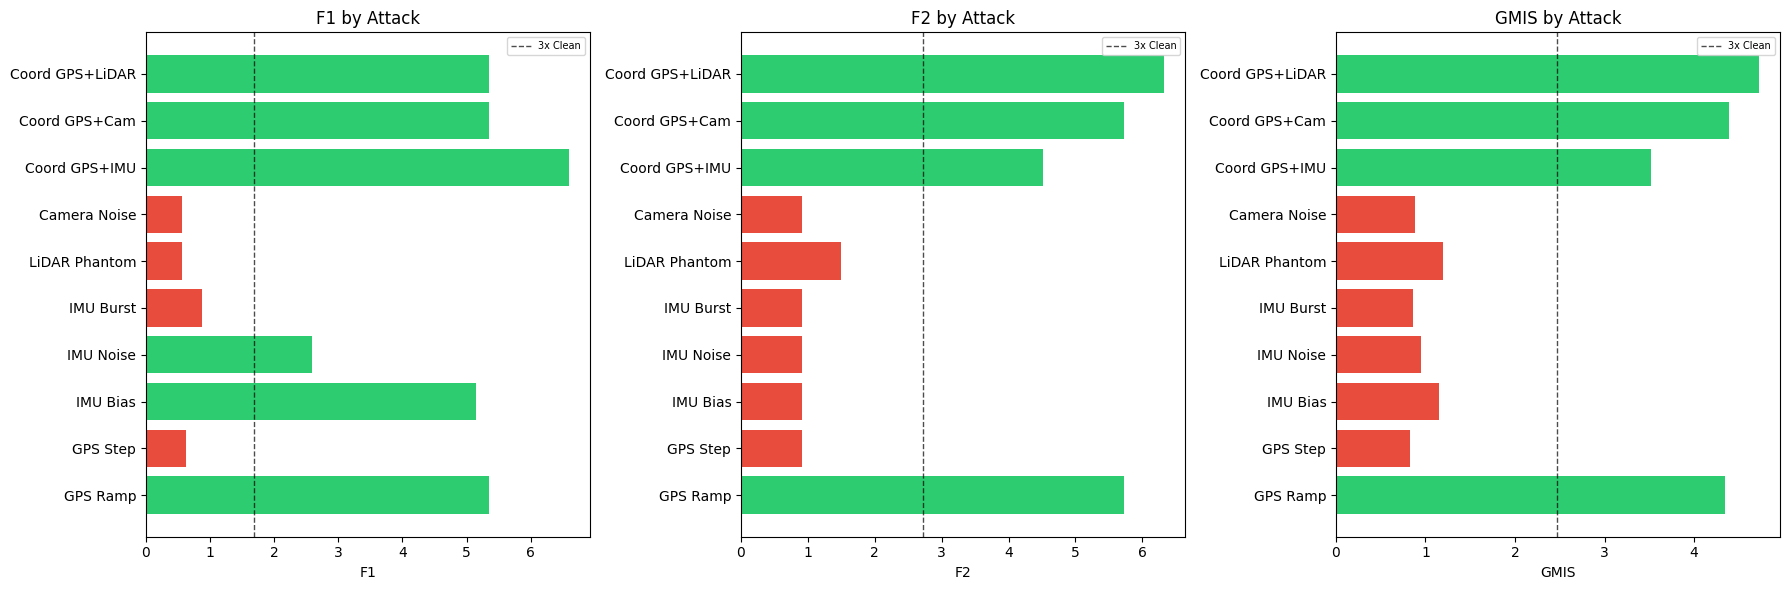

In [46]:
attack_names = [n for n in all_results.keys() if n != 'Clean']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feat, clean_val in zip(axes, ['F1', 'F2', 'GMIS'], [CLEAN_F1, CLEAN_F2, CLEAN_GMIS]):
    values = [all_results[n][feat] for n in attack_names]
    colors_list = ['#2ecc71' if v / clean_val > 3 else '#e74c3c' for v in values]
    
    ax.barh(attack_names, values, color=colors_list)
    ax.axvline(x=clean_val * 3, color='black', linestyle='--', linewidth=1, alpha=0.7, label='3x Clean')
    ax.set_xlabel(feat)
    ax.set_title(f'{feat} by Attack')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()